<a href="https://colab.research.google.com/github/Shresta0506/shresta_INFO5731_Spring2026/blob/main/Panyala_Shresta_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [1]:
import pandas as pd

df = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")
texts = df["c6_lemma"].dropna().tolist()

print(df.head())

                                    paperId  \
0  00000c33779acab142af6c7a6dae8b36fac0805d   
1  0000238f07f151172cf2602588ba762b55c8464b   
2  0000315635be19f6278dbc72597b3065fac405f0   
3  00005d68c6c7eb4d3c27da8242a30b9a498f991e   
4  00005f1b7e976068ca4b5a1b546d9945158b3bfc   

                                               title  \
0  Insights into Household Electric Vehicle Charg...   
1  Personalized Prediction of Response to Smartph...   
2  Abstractive text summarization of low-resource...   
3  Detection of DDoS Attacks on Clouds Computing ...   
4  Diffusion Generative Models for Designing Effi...   

                                            abstract    year  \
0  In the era of burgeoning electric vehicle (EV)...  2024.0   
1  Background Meditation apps have surged in popu...  2021.0   
2  Background Humans must be able to cope with th...  2023.0   
3  The growing number of cloud-based services has...  2023.0   
4  Diffusion generative models, a class of machin...  2024.0

In [2]:
import pandas as pd
import re

df = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")
texts = df["c6_lemma"].dropna().tolist()

# simple tokenization
docs = []
for text in texts:
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    docs.append(words)

# count bigrams and trigrams
bigram_count = {}
trigram_count = {}
word_count = {}

for words in docs:
    for i in range(len(words)):
        w = words[i]
        if w not in word_count:
            word_count[w] = 0
        word_count[w] += 1

        if i < len(words) - 1:
            bg = (words[i], words[i+1])
            if bg not in bigram_count:
                bigram_count[bg] = 0
            bigram_count[bg] += 1

        if i < len(words) - 2:
            tg = (words[i], words[i+1], words[i+2])
            if tg not in trigram_count:
                trigram_count[tg] = 0
            trigram_count[tg] += 1

# top 10 bigrams
top_bigrams = sorted(bigram_count.items(), key=lambda x: x[1], reverse=True)[:10]
top_trigrams = sorted(trigram_count.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 bigrams:")
for item in top_bigrams:
    print(item)

print("\nTop 10 trigrams:")
for item in top_trigrams:
    print(item)

# probability of bigrams
print("\nBigram probabilities:")
for bg, count in top_bigrams:
    first_word = bg[0]
    prob = count / word_count[first_word]
    print(bg, ":", round(prob, 4))

Top 10 bigrams:
(('machine', 'learning'), 12475)
(('neural', 'network'), 2891)
(('learning', 'model'), 2232)
(('deep', 'learning'), 1983)
(('learning', 'algorithm'), 1827)
(('random', 'forest'), 1716)
(('artificial', 'intelligence'), 1299)
(('real', 'time'), 1261)
(('learning', 'ml'), 1222)
(('support', 'vector'), 1200)

Top 10 trigrams:
(('machine', 'learning', 'model'), 1734)
(('machine', 'learning', 'algorithm'), 1519)
(('machine', 'learning', 'ml'), 1215)
(('support', 'vector', 'machine'), 1036)
(('machine', 'learning', 'technique'), 880)
(('machine', 'learning', 'method'), 743)
(('using', 'machine', 'learning'), 622)
(('convolutional', 'neural', 'network'), 617)
(('machine', 'learning', 'approach'), 533)
(('machine', 'learning', 'based'), 531)

Bigram probabilities:
('machine', 'learning') : 0.8352
('neural', 'network') : 0.897
('learning', 'model') : 0.121
('deep', 'learning') : 0.6919
('learning', 'algorithm') : 0.099
('random', 'forest') : 0.8408
('artificial', 'intelligence') 

In [3]:
##Noun phrase part
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")

noun_phrase_count = {}

for text in texts[:200]:   # keep it smaller and simple
    doc = nlp(text)
    for chunk in doc.noun_chunks:
        phrase = chunk.text.strip().lower()
        if phrase not in noun_phrase_count:
            noun_phrase_count[phrase] = 0
        noun_phrase_count[phrase] += 1

top_np = sorted(noun_phrase_count.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top noun phrases:")
for item in top_np:
    print(item)

Top noun phrases:
('algorithm', 33)
('machine learning', 13)
('data', 12)
('paper', 12)
('machine', 12)
('deep learning', 10)
('em', 9)
('u', 9)
('accuracy', 9)
('approach', 9)
('deep learning model', 8)
('ml', 8)
('analysis', 8)
('model', 7)
('method', 7)


## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [1]:
import re
import math
from collections import Counter, defaultdict
import pandas as pd

# load dataset
df = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")
df = df[df["c6_lemma"].notna()].head(100).reset_index(drop=True)

raw_docs = df["c6_lemma"].tolist()
doc_labels = []

for i in range(len(raw_docs)):
    doc_labels.append("Doc_" + str(i+1))

N = len(raw_docs)
print("Loaded", N, "documents")

# custom query
QUERY = "machine learning model prediction classification"

# simple tokenizer
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    clean_words = []
    for w in words:
        if len(w) > 2:
            clean_words.append(w)
    return clean_words

# tokenize all documents
doc_tokens = []
for doc in raw_docs:
    doc_tokens.append(tokenize(doc))

# build vocabulary
vocab_set = set()
for tokens in doc_tokens:
    for token in tokens:
        vocab_set.add(token)

vocab = sorted(list(vocab_set))
print("Vocabulary size:", len(vocab))

#TF

tf_matrix = []

for tokens in doc_tokens:
    counts = Counter(tokens)
    total = len(tokens)

    tf_row = {}
    if total > 0:
        for term, count in counts.items():
            tf_row[term] = count / total

    tf_matrix.append(tf_row)


#  IDF

df_counts = defaultdict(int)

for tf_row in tf_matrix:
    for term in tf_row:
        df_counts[term] += 1

idf = {}
for term in vocab:
    idf[term] = math.log((N + 1) / (df_counts[term] + 1)) + 1


#  TF-IDF

tfidf_matrix = []

for tf_row in tf_matrix:
    tfidf_row = {}
    for term, tf_value in tf_row.items():
        tfidf_row[term] = tf_value * idf[term]
    tfidf_matrix.append(tfidf_row)

print("TF-IDF matrix created successfully")


# Cosine similarity

def dot_product(vec1, vec2):
    total = 0
    for term in vec1:
        if term in vec2:
            total += vec1[term] * vec2[term]
    return total

def vector_norm(vec):
    total = 0
    for value in vec.values():
        total += value * value
    return math.sqrt(total)

def cosine_similarity(vec1, vec2):
    norm1 = vector_norm(vec1)
    norm2 = vector_norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0

    return dot_product(vec1, vec2) / (norm1 * norm2)


#  Query TF-IDF

query_tokens = tokenize(QUERY)
query_counts = Counter(query_tokens)
query_total = len(query_tokens)

query_tf = {}
for term, count in query_counts.items():
    query_tf[term] = count / query_total

query_tfidf = {}
for term, tf_value in query_tf.items():
    if term in idf:
        query_tfidf[term] = tf_value * idf[term]
    else:
        query_tfidf[term] = tf_value * 1.0

print("\nQuery tokens:", query_tokens)


#  Rank documents

scores = []

for i in range(len(tfidf_matrix)):
    sim = cosine_similarity(tfidf_matrix[i], query_tfidf)
    scores.append((doc_labels[i], sim))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("\nTop 10 ranked documents:")
for i in range(10):
    print(i+1, scores[i][0], "->", round(scores[i][1], 4))


#  Show top 5 document snippets

print("\nTop 5 document snippets:")
for i in range(5):
    doc_name = scores[i][0]
    sim_score = scores[i][1]
    doc_index = int(doc_name.split("_")[1]) - 1
    print("\nRank:", i+1)
    print("Document:", doc_name)
    print("Cosine Similarity:", round(sim_score, 4))
    print("Text Snippet:", raw_docs[doc_index][:200])


#  small TF-IDF table

top_terms_each_doc = []

for i in range(len(tfidf_matrix)):
    sorted_terms = sorted(tfidf_matrix[i].items(), key=lambda x: x[1], reverse=True)[:5]
    top_terms_each_doc.append({
        "Document": doc_labels[i],
        "Top Terms": sorted_terms
    })

top_terms_df = pd.DataFrame(top_terms_each_doc)
print("\nSample TF-IDF summary:")
print(top_terms_df.head())

Loaded 100 documents
Vocabulary size: 4236
TF-IDF matrix created successfully

Query tokens: ['machine', 'learning', 'model', 'prediction', 'classification']

Top 10 ranked documents:
1 Doc_40 -> 0.2408
2 Doc_57 -> 0.2037
3 Doc_86 -> 0.1779
4 Doc_24 -> 0.1503
5 Doc_22 -> 0.1458
6 Doc_58 -> 0.1394
7 Doc_78 -> 0.1353
8 Doc_6 -> 0.1312
9 Doc_82 -> 0.1106
10 Doc_72 -> 0.1094

Top 5 document snippets:

Rank: 1
Document: Doc_40
Cosine Similarity: 0.2408
Text Snippet: outbreak cyanobacterial bloom serious water environmental problem harm brings aquatic ecosystem water supply system cannot underestimated important establish accurate prediction model cyanobacterial b

Rank: 2
Document: Doc_57
Cosine Similarity: 0.2037
Text Snippet: accurate crop classification necessary use time series high resolution satellite data better discriminate among certain crop type task brings following challenge large amount satellite data download b

Rank: 3
Document: Doc_86
Cosine Similarity: 0.1779
Text Snippet: 

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


In [1]:
!pip install gensim
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
from gensim.models import Word2Vec

# load dataset
df = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")
texts = df["c6_lemma"].dropna().tolist()

# simple tokenization
sentences = []
for text in texts:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    clean_words = []
    for word in words:
        if len(word) > 2:
            clean_words.append(word)
    sentences.append(clean_words)

# train 300-dimensional word2vec model
model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=2
)

print("Word embedding model trained successfully.")
print("Vocabulary size:", len(model.wv.index_to_key))

Word embedding model trained successfully.
Vocabulary size: 24106


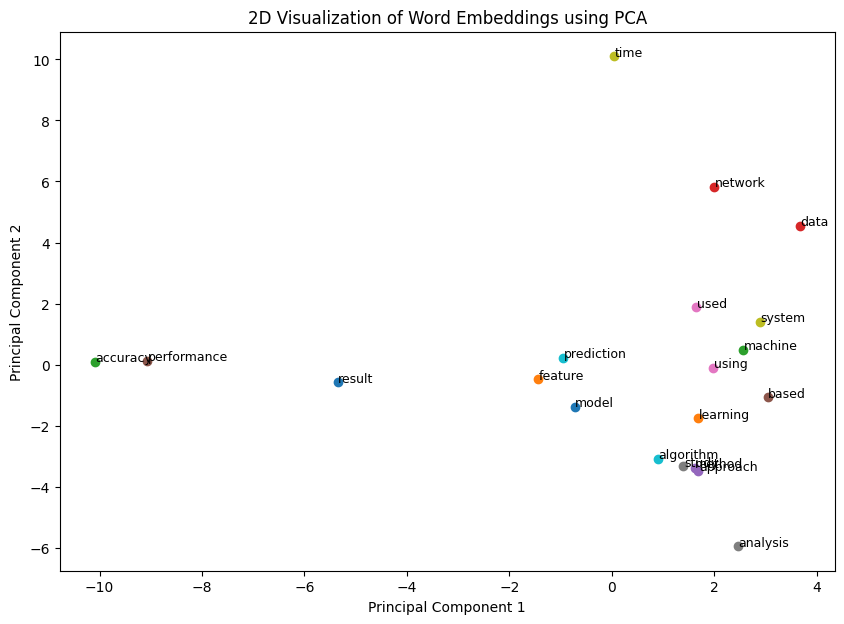

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# take first 20 words from vocabulary
words = model.wv.index_to_key[:20]

vectors = []
for word in words:
    vectors.append(model.wv[word])

# reduce 300 dimensions to 2
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# scatter plot
plt.figure(figsize=(10, 7))

for i in range(len(words)):
    x = result[i][0]
    y = result[i][1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, words[i], fontsize=9)

plt.title("2D Visualization of Word Embeddings using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [4]:
word_pairs = [
    ("data", "information"),
    ("model", "algorithm"),
    ("learning", "training"),
    ("network", "system"),
    ("classification", "prediction")
]

print("Cosine similarity between word pairs:\n")

for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        score = model.wv.similarity(w1, w2)
        print(w1, "-", w2, ":", round(score, 4))
    else:
        print(w1, "-", w2, ": one or both words not in vocabulary")

Cosine similarity between word pairs:

data - information : 0.5768
model - algorithm : 0.6354
learning - training : 0.2566
network - system : 0.4207
classification - prediction : 0.5321


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [6]:
import pandas as pd

df = pd.read_csv("Panyala_Shresta_S2_Abstracts_CLEAN.csv")

df = df[["c6_lemma"]].dropna().head(100).reset_index(drop=True)

new_df = pd.DataFrame()

# create columns
new_df["document_id"] = ["Doc_" + str(i+1) for i in range(len(df))]
new_df["clean_text"] = df["c6_lemma"]

# create labels (simple rule-based)
labels = []

for text in new_df["clean_text"]:
    text = text.lower()

    if "neural" in text or "learning" in text:
        labels.append("Machine Learning")
    elif "data" in text or "analysis" in text:
        labels.append("Data Science")
    elif "ai" in text or "artificial" in text:
        labels.append("Artificial Intelligence")
    else:
        labels.append("Information Extraction")

new_df["label"] = labels

new_df.head()

,document_id,clean_text,label
0,Doc_1,era burgeoning electric vehicle ev popularity ...,Machine Learning
1,Doc_2,background meditation apps surged popularity r...,Machine Learning
2,Doc_3,background human must able cope huge amount in...,Machine Learning
3,Doc_4,growing number cloud based service led rising ...,Machine Learning
4,Doc_5,diffusion generative model class machine learn...,Machine Learning


In [7]:
new_df.to_csv("annotated_dataset.csv", index=False)

In [8]:
from google.colab import files
files.download("annotated_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#github link
https://github.com/Shresta0506/shresta_INFO5731_Spring2026/blob/main/annotated_dataset.csv

1. I chose to perform **text classification** on my dataset.

2. The labeling schema is based on the topic of each research abstract. The labels used are:
- Machine Learning
- Data Science
- Artificial Intelligence
- Information Extraction

Each abstract was assigned a label based on the main keywords and focus of the text.

3. I used AI assistance to help generate initial labels using keyword-based classification, and then manually reviewed the labels to ensure correctness.

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
# Type your answer
#This assignment gave me hands-on experience with key NLP concepts like N-grams, TF-IDF, and word embeddings. I learned each step in detail while working through the problems, especially when using AI tools alongside my own understanding.

#The most challenging part was implementing TF-IDF and cosine similarity efficiently, but it helped me think more critically about the logic and improve my coding approach.

#Overall, I found the assignment useful for both learning and practical experience, and the time provided was sufficient to complete it.